# Import libraries and generate data

In [1]:
import numpy as np

# Seed
np.random.seed(42)

# Simulate some data
n, p = 100, 10  # Number of observations and features
X = np.random.randn(n, p)
Xsub = X[:,:5]
print(X.shape)

true_beta = np.random.randn(5).reshape(-1,1)
y = np.matmul(Xsub, true_beta) + 0.5 * np.random.randn(n).reshape(-1,1)  # Adding some noise
print(y.shape)

(100, 10)
(100, 1)


In [3]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pipeline and some hyperparameters

In [4]:
# Create a pipeline that standardizes the data then fits the Lasso model
lambda_ = 0.5
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(alpha=lambda_, fit_intercept=True))

# Fit using `sklearn`

In [5]:
# Fit the model
lasso_pipeline.fit(X, y.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


# Get results

In [6]:
# Get the estimated coefficients and intercept
lasso_model = lasso_pipeline.named_steps['lasso']
beta_estimated = lasso_model.coef_
intercept = lasso_model.intercept_

# Print the estimated coefficients and intercept
print("Intercept:", intercept)
print("Estimated coefficients:", beta_estimated)
print("True coefficients:", true_beta)

Intercept: 0.06326823555397829
Estimated coefficients: [ 0.65095652  0.42377436  0.         -0.29798286  0.29193259 -0.
 -0.          0.         -0.         -0.        ]
True coefficients: [[ 1.39935544]
 [ 0.92463368]
 [ 0.05963037]
 [-0.64693678]
 [ 0.69822331]]


# Fit using cross-validation

In [7]:
from sklearn.linear_model import LassoCV

In [8]:
# Create a pipeline with standardization and LassoCV
lasso_cv_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42)  # 5-fold cross-validation
)

In [9]:
# Fit the pipeline
lasso_cv_pipeline.fit(X, y.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lassocv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [10]:
# Retrieve the fitted LassoCV model
lasso_cv_model = lasso_cv_pipeline.named_steps['lassocv']

In [11]:
# Get the optimal alpha (lambda)
optimal_alpha = lasso_cv_model.alpha_

# Get the estimated coefficients and intercept
beta_estimated = lasso_cv_model.coef_
intercept = lasso_cv_model.intercept_

# Print the results
print("Optimal alpha (lambda):", optimal_alpha)
print("Intercept:", intercept)
print("Estimated coefficients:", beta_estimated)
print("True coefficients:", true_beta)

Optimal alpha (lambda): 0.05215236729770642
Intercept: 0.0632682355539783
Estimated coefficients: [ 1.12083159  0.84104746  0.04218801 -0.68778333  0.67293769 -0.00344116
  0.         -0.         -0.         -0.        ]
True coefficients: [[ 1.39935544]
 [ 0.92463368]
 [ 0.05963037]
 [-0.64693678]
 [ 0.69822331]]


# Implement coordinate descent

In [12]:
def soft_thresholding(x, lambda_):
    if x > 0 and lambda_ < np.abs(x):
        return x - lambda_
    elif x < 0 and lambda_ < np.abs(x):
        return x + lambda_
    else:
        return 0

def coordinate_descent_lasso_with_intercept(X, y, lambda_, num_iterations=1000, tol=1e-6):
    n, p = X.shape
    # Standardize X and center y
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0, ddof=0)
    y_mean = np.mean(y)
    
    X_std[X_std == 0] = 1  # To avoid division by zero for constant columns
    X_scaled = (X - X_mean) / X_std
    y_centered = y - y_mean

    beta = np.zeros(p)
    for iteration in range(num_iterations):
        beta_old = beta.copy()
        for j in range(p):
            residual = y_centered - X_scaled @ beta + beta[j] * X_scaled[:, j]
            rho = X_scaled[:, j].T @ residual
            beta[j] = soft_thresholding(rho / (X_scaled[:, j].T @ X_scaled[:, j]), lambda_)
        # Check for convergence (change in coefficients)
        if np.linalg.norm(beta - beta_old, ord=2) < tol:
            print(f"Converged after {iteration + 1} iterations")
            break

    # Compute the intercept using the non-centered response
    intercept = y_mean - np.mean(X, axis=0) @ beta
    return intercept, beta

# Fit lasso with coordinate descent

In [13]:
# Run the coordinate descent algorithm 
intercept, beta_estimated = coordinate_descent_lasso_with_intercept(X, y.ravel(), lambda_)

# Print the estimated coefficients and intercept
print("Intercept:", intercept)
print("Estimated coefficients:", beta_estimated)
print("True coefficients:", true_beta)

Converged after 5 iterations
Intercept: 0.06908491318685489
Estimated coefficients: [ 0.65095709  0.42377457  0.         -0.29798286  0.29193257  0.
  0.          0.          0.          0.        ]
True coefficients: [[ 1.39935544]
 [ 0.92463368]
 [ 0.05963037]
 [-0.64693678]
 [ 0.69822331]]


# Compare with `sklearn`

In [14]:
lambda_ = 0.5
lasso_pipeline = make_pipeline(StandardScaler(), Lasso(alpha=lambda_, fit_intercept=True))

lasso_pipeline.fit(X, y.ravel())

lasso_model = lasso_pipeline.named_steps['lasso']
beta_estimated2 = lasso_model.coef_
intercept2 = lasso_model.intercept_

print("Intercept:", intercept2)
print("Estimated coefficients:", beta_estimated2)
print("True coefficients:", true_beta)

Intercept: 0.06326823555397829
Estimated coefficients: [ 0.65095652  0.42377436  0.         -0.29798286  0.29193259 -0.
 -0.          0.         -0.         -0.        ]
True coefficients: [[ 1.39935544]
 [ 0.92463368]
 [ 0.05963037]
 [-0.64693678]
 [ 0.69822331]]


In [15]:
def coordinate_descent_lasso_with_intercept_with_history(X, y, lambda_, num_iterations=1000, tol=1e-6):
    n, p = X.shape
    # Standardize X and center y
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0, ddof=0)
    y_mean = np.mean(y)
    
    X_std[X_std == 0] = 1  # To avoid division by zero for constant columns
    X_scaled = (X - X_mean) / X_std
    y_centered = y - y_mean

    beta = np.zeros(p)
    beta_hist = np.zeros(shape = (1, p))
    beta_hist_all = np.zeros(shape=(1,p))
    for iteration in range(num_iterations):
        beta_old = beta.copy()
        for j in range(p):
            residual = y_centered - X_scaled @ beta + beta[j] * X_scaled[:, j]
            rho = X_scaled[:, j].T @ residual
            beta[j] = soft_thresholding(rho / (X_scaled[:, j].T @ X_scaled[:, j]), lambda_)
            beta_hist_all = np.concatenate((beta_hist_all, beta.reshape(1,-1)), axis=0)
        # Check for convergence (change in coefficients)
        beta_hist = np.concatenate((beta_hist, beta.reshape(1,-1)), axis=0)
        if np.linalg.norm(beta - beta_old, ord=2) < tol:
            print(f"Converged after {iteration + 1} iterations")
            break

    # Compute the intercept using the non-centered response
    intercept = y_mean - np.mean(X, axis=0) @ beta
    return intercept, beta, beta_hist, beta_hist_all

In [16]:
# Run the coordinate descent algorithm 
intercept, beta_estimated, beta_hist, beta_hist_all = coordinate_descent_lasso_with_intercept_with_history(X, y.ravel(), lambda_)

# Print the estimated coefficients and intercept
print("Intercept:", intercept)
print("Estimated coefficients:", beta_estimated)
print("True coefficients:", true_beta)

Converged after 5 iterations
Intercept: 0.06908491318685489
Estimated coefficients: [ 0.65095709  0.42377457  0.         -0.29798286  0.29193257  0.
  0.          0.          0.          0.        ]
True coefficients: [[ 1.39935544]
 [ 0.92463368]
 [ 0.05963037]
 [-0.64693678]
 [ 0.69822331]]


In [17]:
beta_hist.shape

(6, 10)

In [19]:
import matplotlib.pyplot as plt

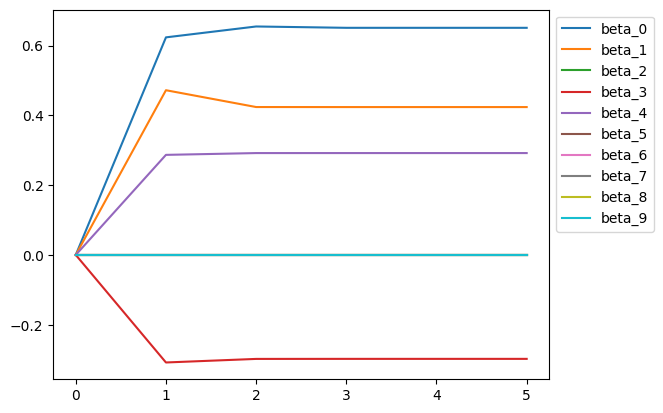

In [20]:
plt.figure()
for i in range(beta_hist.shape[1]):
    all_beta_i = beta_hist[:,i]
    plt.plot(all_beta_i, label = f'beta_{i}')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [21]:
beta_hist_all.shape

(51, 10)

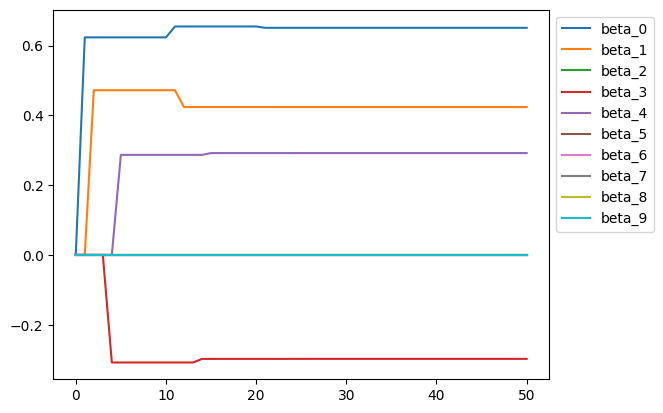

In [22]:
plt.figure()
for i in range(beta_hist_all.shape[1]):
    all_beta_i = beta_hist_all[:,i]
    plt.plot(all_beta_i, label = f'beta_{i}')
plt.legend(bbox_to_anchor = (1,1))
plt.show()